# Getting Started: Bayesian Workflow with ProbPipe

This tutorial walks through an iterative Bayesian modeling workflow using ProbPipe, following the principles outlined in [Bayesian Workflow](https://arxiv.org/abs/2011.01808) (Gelman et al., 2020). The key idea is that applied Bayesian analysis is *iterative*: we start with a simple model, check it against data, revise, and repeat. ProbPipe is designed to make this process computationally efficient and statistically rigorous.

### Why ProbPipe?

Most workflows for probabilistic inference can be described in terms of **distributions**, **fixed values** (data, hyperparameters, covariates), **operations** that transform distributions, and **differentiation** with respect to fixed values. Implementing these workflows, however, is harder than describing them:

1. **Algorithmic challenges** — there are many possible algorithms for common operations, with varying trade-offs that need to be explored in a problem-specific manner. A posterior could be approximated using different Markov chain Monte Carlo (MCMC) algorithms, variational inference, or sequential Monte Carlo.
2. **Representational challenges** — algorithms require — and output — specific formats for both distributions and fixed values that are not always compatible with other parts of the workflow. Fixed values may be named parameter vectors, covariate matrices, or structured observations — and different algorithms expect different representations.

### Simplification via abstraction

ProbPipe addresses these challenges through a single design principle: **simplification via abstraction**. There are just three core types:

- **`Distribution`** — the universal representation of random quantities (priors, posteriors, data-generating processes). A distribution's capabilities are declared via protocols (`SupportsSampling`, `SupportsLogProb`, ...), and ProbPipe converts between representations as needed.
- **`Record`** — the universal container for non-random structured data (observed datasets, hyperparameters, design matrices). `Record` is the deterministic counterpart of `Distribution`.
- **`WorkflowFunction`** — operations that transform distributions. Write a function that takes fixed values, and ProbPipe propagates uncertainty when those values are instead uncertain (i.e., distributions).

`Distribution` and `Record` follow the same syntax for accessing their components and passing those components into a `WorkflowFunction`, so they can easily be interchanged. Both support **named fields** and a **`select()`** method for splatting (e.g., `predict(**posterior.select("intercept", "slope"))`). The implementation details — algorithms, data and distribution representations — are invisible to the user, while remaining fully configurable when control is needed.

### Built-in operations

ProbPipe provides a set of built-in **ops** — special workflow functions that dispatch based on a distribution's protocols:

- **`condition_on`** — condition a model on observed data, automatically selecting the best inference algorithm (or specify one with `method=`).
- **`mean`**, **`variance`**, **`cov`**, **`expectation`** — compute distributional summaries, with automatic Monte Carlo fallback when exact computation is unavailable.
- **`sample`**, **`log_prob`** — draw samples or evaluate densities through a uniform interface.
- **`from_distribution`** — convert between distribution representations via the converter registry.
- **`predictive_check`** — built-in prior and posterior predictive checking.

## Running example: modeling count data

To illustrate ProbPipe's features, we analyze the **horseshoe crab satellite** dataset (Brockmann, 1996; Agresti, 2007). Each nesting female horseshoe crab may attract "satellite" males. The response is the **count of satellites**, with the female's **carapace width** (cm) as the primary covariate.

In [1]:
import warnings
warnings.filterwarnings('ignore', message=r'Explicitly requested dtype.*float64.*')
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

import jax, jax.numpy as jnp, numpy as np, matplotlib.pyplot as plt
import pandas as pd
import tensorflow_probability.substrates.jax.glm as tfp_glm

from probpipe import (
    Record, Normal, ProductDistribution,
    EmpiricalDistribution, BootstrapReplicateDistribution,
    GLMLikelihood, SimpleModel,
    condition_on, from_distribution, sample, mean, variance,
    workflow_function, predictive_check, provenance_ancestors,
)
from probpipe.modeling import IncrementalConditioner

In [2]:
# Load horseshoe crab data (Brockmann 1996, Agresti 2007)
df = pd.read_csv("data/horseshoe_crabs.csv")
print(df)

     width_cm  satellites
0        28.3           8
1        22.5           0
2        26.0           9
3        24.8           0
4        26.0           4
..        ...         ...
167      32.5           0
168      23.5           0
169      26.5           6
170      25.5           3
171      22.5           1

[172 rows x 2 columns]


In [3]:
# Standardize covariates and build design matrix
x_mean = float(df['width_cm'].mean())
x_std = float(df['width_cm'].std())

@workflow_function
def prep_data(width, satellites) -> Record:
    width = np.asarray(width, dtype=np.float32)
    width_z = (width - np.mean(width)) / np.std(width)
    X = np.column_stack([np.ones(len(width)), width_z]).astype(np.float32)
    return Record(X=X, y=np.asarray(satellites, dtype=np.float32))


data = prep_data(df['width_cm'], df['satellites'])
print(data)

Record(X=array(shape=(172, 2)), y=array(shape=(172,)))


## 1. Choose an initial model

We start simple: a **Poisson regression** for count data, $y_i \sim \text{Poisson}(\exp(\boldsymbol{x}_i^\top \boldsymbol{\beta}))$.

`GLMLikelihood` wraps a TFP generalized linear model (GLM) family and a design matrix into a ProbPipe likelihood that supports both inference and data generation. Models can also be defined using PyMC, Stan, or TFP directly (see §10).

In [ ]:
lik_poisson = GLMLikelihood(tfp_glm.Poisson(), data.X)
# Named prior — posterior draws will have .intercept and .slope fields
prior = ProductDistribution(intercept=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
                            slope=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"))
model_poisson = SimpleModel(prior, lik_poisson, name='poisson')

## 2. Prior predictive checking

Before fitting, we check whether the prior implies plausible data. `predictive_check` draws parameters from the prior, generates replicated data, and computes a summary statistic. Without `observed_data`, it acts as a **prior predictive check**.

In [5]:
prior_check = predictive_check(prior, lik_poisson, test_fn=jnp.mean,
                               n_samples=len(data.y))
prior_means = np.array(prior_check['replicated_statistics'].samples)
print(f'Prior predictive mean: median={np.median(prior_means):.1f}, '
      f'90th pct={np.percentile(prior_means, 90):.1f}')
print(f'Observed mean: {data.y.mean():.2f}')

Prior predictive mean: median=5.7, 90th pct=1003.7
Observed mean: 2.34


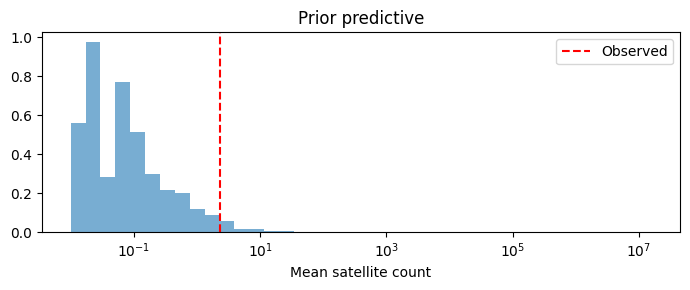

In [6]:
fig, ax = plt.subplots(figsize=(7, 3))
bins = np.logspace(np.log10(max(prior_means.min(), 0.01)),
                   np.log10(prior_means.max()), 40)
ax.hist(prior_means, bins=bins, density=True, alpha=0.6)
ax.axvline(float(data.y.mean()), color='red', ls='--', label='Observed')
ax.set(xlabel='Mean satellite count', title='Prior predictive')
ax.set_xscale('log'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Fit the model

`condition_on` runs MCMC via the **inference method registry**, which auto-selects the best available algorithm — the No-U-Turn Sampler (NUTS) when the log-density is JAX-traceable, gradient-free random-walk Metropolis–Hastings (RWMH) otherwise. Pass `method="tfp_hmc"` (or any registered name) to override. The result is an `ApproximateDistribution` with chain structure and diagnostics.

In [7]:
posterior_poisson = condition_on(model_poisson, data.y)
print(f'Posterior mean: {mean(posterior_poisson)}')

Posterior mean: [0.6659561  0.59836555]


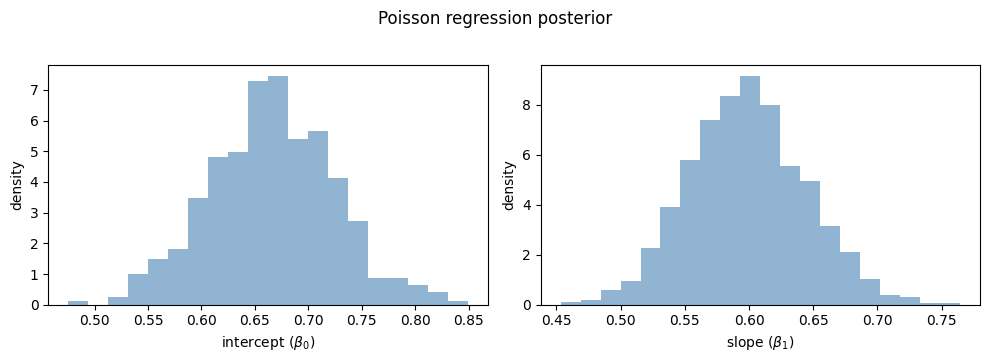

In [8]:
draws = posterior_poisson.draws()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, name in zip(axes, ['intercept', 'slope']):
    label = f'{name} ($\\beta_0$)' if name == 'intercept' else f'{name} ($\\beta_1$)'
    ax.hist(np.asarray(getattr(draws, name)), bins=20, density=True, alpha=0.6, color='steelblue')
    ax.set(xlabel=label, ylabel="density")
plt.suptitle('Poisson regression posterior', y=1.02)
plt.tight_layout(); plt.show()

## 4. Provenance tracking

Every distribution records how it was created — the algorithm, parents, and metadata. This enables full lineage tracing from any result back to its inputs.

In [9]:
print(posterior_poisson.source)

Provenance('tfp_nuts', parents=[ProductDistribution])


## 5. Posterior predictive checking

Does the fitted model reproduce key features of the data? With `observed_data`, `predictive_check` also returns a calibration **p-value**. We check two statistics: the **variance-to-mean ratio** (a standard overdispersion diagnostic for count data) and the **fraction of zeros**.

In [10]:
var_mean_ratio = lambda d: float(jnp.var(d) / jnp.maximum(jnp.mean(d), 1e-6))
zero_fraction = lambda d: float(jnp.mean(d == 0))

ppc_vmr = predictive_check(posterior_poisson, lik_poisson, var_mean_ratio, observed_data=data.y)
ppc_zeros = predictive_check(posterior_poisson, lik_poisson, zero_fraction, observed_data=data.y)

print(f"Var/mean ratio — observed: {ppc_vmr['observed_statistic']:.2f}, p={ppc_vmr['p_value']:.3f}")
print(f"Zero fraction  — observed: {ppc_zeros['observed_statistic']:.2f}, p={ppc_zeros['p_value']:.3f}")

Var/mean ratio — observed: 4.14, p=0.000
Zero fraction  — observed: 0.47, p=0.000


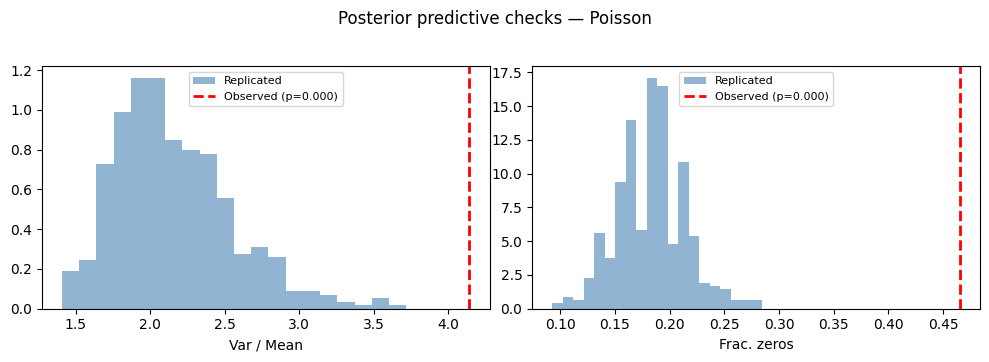

In [11]:
def plot_ppc(checks, labels, title):
    fig, axes = plt.subplots(1, len(checks), figsize=(5 * len(checks), 3.5))
    for ax, check, label in zip(axes, checks, labels):
        ax.hist(np.array(check['replicated_statistics'].samples), bins=20,
                density=True, alpha=0.6, color='steelblue', label='Replicated')
        ax.axvline(check['observed_statistic'], color='red', ls='--', lw=2,
                   label=f"Observed (p={check['p_value']:.3f})")
        ax.set(xlabel=label); ax.legend(fontsize=8)
    plt.suptitle(title, y=1.02)
    plt.tight_layout(); plt.show()

plot_ppc([ppc_vmr, ppc_zeros], ['Var / Mean', 'Frac. zeros'],
         'Posterior predictive checks — Poisson')

Both checks **fail** — the Poisson model cannot reproduce the overdispersion or the excess zeros in the observed data. This motivates revising the model.

## 6. Revise and compare models

The **negative binomial** naturally handles overdispersion. With `GLMLikelihood`, swapping is a one-line change — just replace the TFP family.

In [ ]:
lik_nb = GLMLikelihood(tfp_glm.NegativeBinomial(), data.X)
model_nb = SimpleModel(
    # Named prior — posterior draws will have .intercept and .slope fields
    ProductDistribution(
        intercept=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
        slope=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"),
    ),
    lik_nb, name='negbin',
)

posterior_nb = condition_on(
    model_nb, data.y,
)
print(f'NegBin posterior mean: {mean(posterior_nb)}')

Var/mean ratio — p=0.974 (was 0.000 for Poisson)
Zero fraction  — p=0.030 (was 0.000 for Poisson)


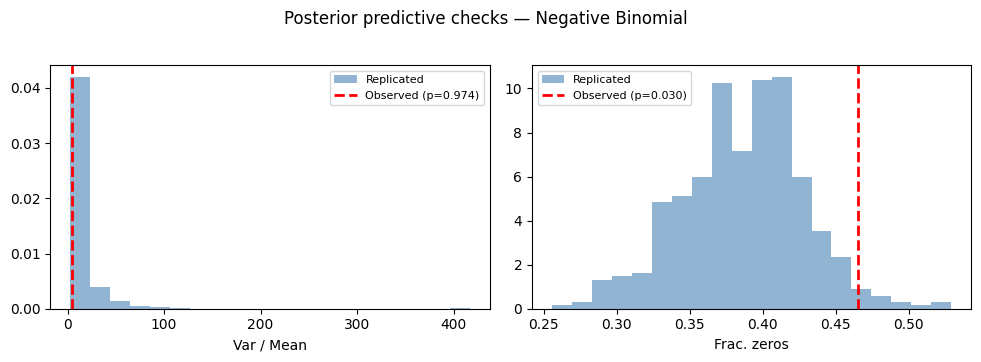

In [13]:
ppc_nb_vmr = predictive_check(posterior_nb, lik_nb, var_mean_ratio, observed_data=data.y)
ppc_nb_zeros = predictive_check(posterior_nb, lik_nb, zero_fraction, observed_data=data.y)

print(f"Var/mean ratio — p={ppc_nb_vmr['p_value']:.3f} (was {ppc_vmr['p_value']:.3f} for Poisson)")
print(f"Zero fraction  — p={ppc_nb_zeros['p_value']:.3f} (was {ppc_zeros['p_value']:.3f} for Poisson)")

plot_ppc([ppc_nb_vmr, ppc_nb_zeros], ['Var / Mean', 'Frac. zeros'],
         'Posterior predictive checks — Negative Binomial')

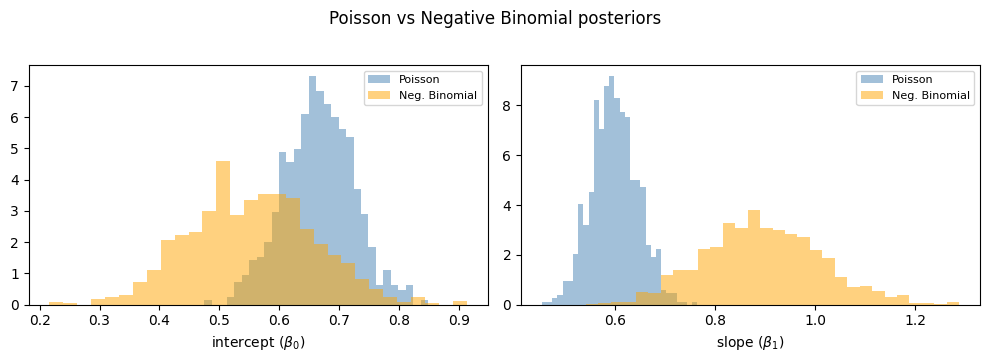

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for ax, name in zip(axes, ['intercept', 'slope']):
    label = f'{name} ($\\beta_0$)' if name == 'intercept' else f'{name} ($\\beta_1$)'
    ax.hist(np.asarray(getattr(posterior_poisson.draws(), name)), bins=30, density=True,
            alpha=0.5, color='steelblue', label='Poisson')
    ax.hist(np.asarray(getattr(posterior_nb.draws(), name)), bins=30, density=True,
            alpha=0.5, color='orange', label='Neg. Binomial')
    ax.set(xlabel=label); ax.legend(fontsize=8)
plt.suptitle('Poisson vs Negative Binomial posteriors', y=1.02)
plt.tight_layout(); plt.show()

The negative binomial posteriors are wider and shifted — reflecting greater uncertainty once overdispersion is accounted for. Misspecification appears to lead to the Poisson model's biased and narrow posteriors. 

## 7. Bagged posteriors

Under model misspecification, standard posteriors can be unreliable — credible sets from different datasets may not overlap. The **bagged posterior** (Huggins & Miller, 2024) averages over posteriors conditioned on bootstrapped datasets, yielding reproducible uncertainty quantification.

`BootstrapReplicateDistribution` wraps data as a distribution over bootstrap datasets. When `data` is a `Record` (with named fields like `X` and `y`), rows are resampled **jointly** across all fields — preserving the per-observation relationship between covariates and response. Named field access (`bootstrap.X`, `bootstrap.y`) returns distribution views that, when passed to `condition_on` as named kwargs, are **sampled jointly** from the same parent — correlation is preserved automatically.

We use `n_broadcast_samples=16` to control the number of bootstrap replicates and `parallel=True` to run MCMC fits concurrently. (For even greater scalability, ProbPipe supports Prefect orchestration to distribute fits across machines.)

We compare bagging for the Poisson and negative binomial models. If the individual posteriors are tightly clustered, the model is stable across datasets; if they spread apart, the model is sensitive to the specific dataset — a sign of misspecification.

In [40]:
# Record-native bootstrap: rows are resampled jointly across X and y
bootstrap = BootstrapReplicateDistribution(EmpiricalDistribution(data))

# bootstrap.X and bootstrap.y are distribution views from the same parent,
# so condition_on samples them jointly — preserving row correspondence.
bagged_poisson = condition_on(model_poisson, X=bootstrap.X, y=bootstrap.y,
                              n_broadcast_samples=32, parallel=True)
bagged_nb = condition_on(model_nb, X=bootstrap.X, y=bootstrap.y,
                         n_broadcast_samples=16, parallel=True)

In [41]:
# Sampling variability ratio: Var(individual means) / Var(bagged posterior)
# Ratios > 0.5 indicate unstable inference
for label, bagged in [('Poisson', bagged_poisson), ('NegBin', bagged_nb)]:
    ind_means = np.array([np.array(mean(p)) for p in bagged.components])
    # Pool draws from all component posteriors
    all_draws = np.concatenate([np.asarray(p.draws().flatten()) for p in bagged.components])
    ratio = np.var(ind_means, axis=0) / np.var(all_draws, axis=0)
    print(f'{label}: sampling variability ratio = {np.array2string(ratio, precision=3)}')

Poisson: sampling variability ratio = [0.804 0.814]
NegBin: sampling variability ratio = [0.15  0.169]


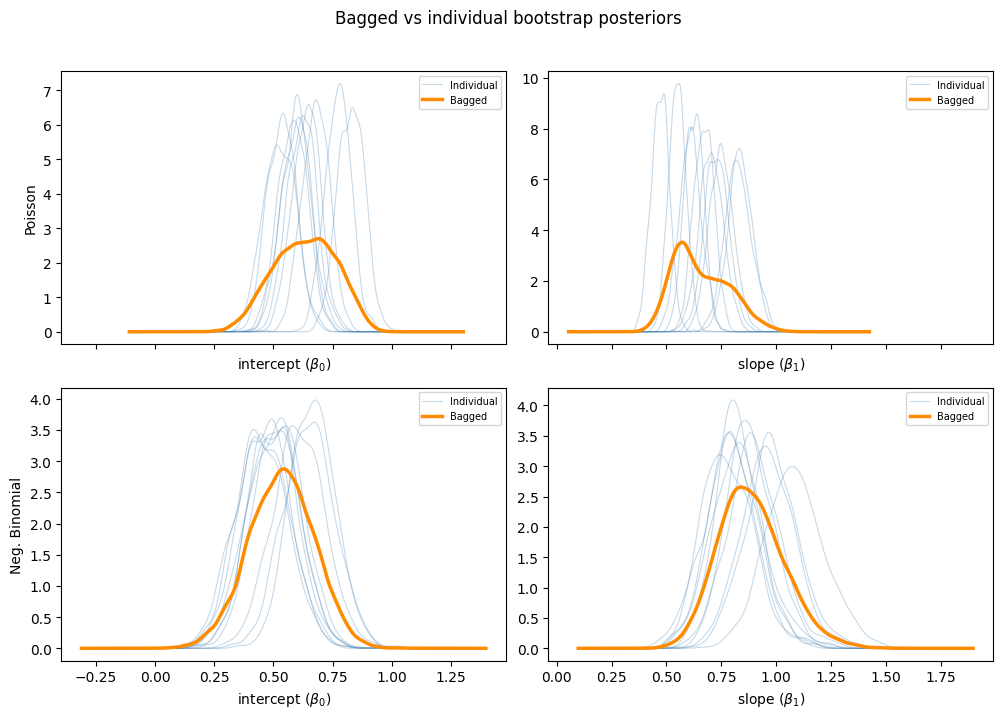

In [42]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex='col')

for row, (bagged, label) in enumerate([(bagged_poisson, 'Poisson'), (bagged_nb, 'Neg. Binomial')]):
    for col, name in enumerate(['intercept', 'slope']):
        param_label = f'{name} ($\\beta_0$)' if name == 'intercept' else f'{name} ($\\beta_1$)'
        ax = axes[row, col]
        # Individual bootstrap posteriors
        for i, post in enumerate(bagged.components[:10]):
            d = np.asarray(getattr(post.draws(), name))
            xs = np.linspace(d.min() - 0.3, d.max() + 0.3, 200)
            ax.plot(xs, gaussian_kde(d)(xs), alpha=0.3, lw=0.8, color='steelblue',
                    label='Individual' if i == 0 else None)
        # Bagged posterior: pool draws from all components
        bd = np.concatenate([np.asarray(getattr(p.draws(), name)) for p in bagged.components])
        xs = np.linspace(bd.min() - 0.3, bd.max() + 0.3, 200)
        ax.plot(xs, gaussian_kde(bd)(xs), color='darkorange', lw=2.5, label='Bagged')
        ax.set(xlabel=param_label); ax.legend(fontsize=7)
        if col == 0:
            ax.set_ylabel(label)

plt.suptitle('Bagged vs individual bootstrap posteriors', y=1.02)
plt.tight_layout(); plt.show()

The Poisson individual posteriors spread apart noticeably. The Poisson bagged posterior for the slope captures the range of plausible values under the negative binomial model. The posteriors for the negative binomial are stable, reflecting a better-specified model.

## 8. Sequential updating

 chains posterior updates across data batches. It automatically converts the MCMC posterior to a smooth KDE before using it as the next prior (since NUTS requires a continuous density). Pass each batch's data fields as named kwargs — the same conditioner handles all updates.

In [ ]:
X, y = np.asarray(data.X, dtype=np.float32), np.asarray(data.y, dtype=np.float32)
n = len(y)
batch_ends = [40, 80, 130, n]
batches_X = [X[:batch_ends[0]]] + [X[s:e] for s, e in zip(batch_ends[:-1], batch_ends[1:])]
batches_y = [y[:batch_ends[0]]] + [y[s:e] for s, e in zip(batch_ends[:-1], batch_ends[1:])]

prior = ProductDistribution(
    intercept=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="intercept"),
    slope=Normal(loc=0.0, scale=jnp.sqrt(5.0), name="slope"),
)

# One conditioner for all batches — pass data fields as named kwargs
conditioner = IncrementalConditioner(
    prior, GLMLikelihood(tfp_glm.NegativeBinomial()),
)

seq_posteriors = []
total = 0
for Xi, yi in zip(batches_X, batches_y):
    conditioner.update(X=Xi, y=yi)
    seq_posteriors.append(conditioner.curr_posterior)
    total += len(yi)
    print(f'n={total}: mean = {mean(conditioner.curr_posterior)}')

print(f'\nFull-data posterior mean: {mean(posterior_nb)}')

Provenance is particularly valuable for sequential pipelines — the lineage traces back through each conditioning step, making the full chain of updates auditable.

In [16]:
ancestors = provenance_ancestors(seq_posteriors[-1])
print(f'Sequential posterior ancestors: {[type(a).__name__ for a in ancestors]}')

Sequential posterior ancestors: ['KDEDistribution', 'ApproximateDistribution', 'KDEDistribution', 'ApproximateDistribution', 'KDEDistribution', 'ApproximateDistribution', 'ProductDistribution']


## 9. Propagate uncertainty

As we saw with `predictive_check` and `condition_on`, ProbPipe automatically broadcasts over distributions. Here's another example: propagating posterior uncertainty through a prediction function.

In [17]:
@workflow_function
def predict_rate(intercept, slope, x):
    return jnp.exp(intercept + slope * x)

rate_dist = predict_rate(**posterior_nb.select("intercept", "slope"), x=0.0)
print(f'Rate at mean width: {float(mean(rate_dist)):.2f} '
      f'(+/- {float(jnp.sqrt(variance(rate_dist))):.2f})')

Rate at mean width: 1.76 (+/- 0.20)


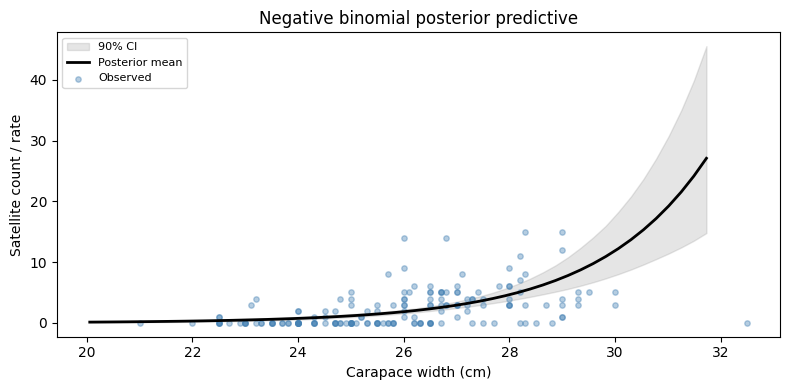

In [18]:
x_grid_z = jnp.linspace(-3, 3, 50)
x_grid_cm = np.array(x_grid_z) * x_std + x_mean
draws = posterior_nb.draws()
rates = np.exp(np.asarray(draws.intercept)[:, None] + np.asarray(draws.slope)[:, None] * np.array(x_grid_z)[None, :])
lo, hi = np.percentile(rates, [5, 95], axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.fill_between(x_grid_cm, lo, hi, alpha=0.2, color='gray', label='90% CI')
ax.plot(x_grid_cm, rates.mean(axis=0), 'k-', lw=2, label='Posterior mean')
ax.scatter(df['width_cm'], np.asarray(data.y), s=15, alpha=0.4, color='steelblue', label='Observed')
ax.set(xlabel='Carapace width (cm)', ylabel='Satellite count / rate',
       title='Negative binomial posterior predictive')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 10. Inference registry and external backends

Every call to `condition_on` is dispatched through a pluggable **inference method registry**. The registry ranks feasible methods by priority and auto-selects the best one — but you can override with `method=`. Registered methods span MCMC algorithms (NUTS, HMC, RWMH via TFP; nutpie; CmdStan; PyMC) and variational inference (black-box variational inference (BBVI) via PyMC ADVI).

In [19]:
from probpipe.inference import inference_method_registry

# List all registered inference methods (highest priority first)
inference_method_registry.list_methods()

['tfp_nuts',
 'tfp_hmc',
 'nutpie_nuts',
 'cmdstan_nuts',
 'pymc_nuts',
 'tfp_rwmh',
 'sbijax_smcabc',
 'pymc_advi']

In [ ]:
import warnings
warnings.filterwarnings('ignore', message=r'install "ipywidgets"')

import pymc as pm
from probpipe.modeling import PyMCModel

x_z = np.asarray(data.X[:, 1])  # standardized covariate column

def poisson_model(y=None):
    with pm.Model() as m:
        beta = pm.Normal('beta', 0, 3, shape=2)
        rate = pm.math.exp(beta[0] + beta[1] * x_z)
        pm.Poisson('y', mu=rate, observed=y)
    return m

posterior_pymc = condition_on(PyMCModel(poisson_model), np.asarray(data.y))
print(f'PyMC posterior mean: {mean(posterior_pymc)}')

Stan and nutpie are also supported — the inference registry auto-selects the right backend:

```python
# Stan (requires BridgeStan + CmdStanPy)
from probpipe.modeling import StanModel
posterior = condition_on(StanModel('model.stan'), {'y': y_sat})

# nutpie (Rust-based NUTS) — use method= to override the default
posterior = condition_on(model_poisson, y_sat, method="nutpie_nuts")

# PyMC ADVI — fast variational approximation
posterior = condition_on(PyMCModel(poisson_model), y_sat, method="pymc_advi")
```

### References

- Gelman, A., Vehtari, A., Simpson, D., et al. (2020). [Bayesian Workflow](https://arxiv.org/abs/2011.01808). *arXiv:2011.01808*.
- Brockmann, H.J. (1996). Satellite male groups in horseshoe crabs, *Limulus polyphemus*. *Ethology*, 102(1), 1–21.
- Huggins, J.H. & Miller, J.W. (2024). [Reproducible Model Selection Using Bagged Posteriors](https://doi.org/10.1214/24-EJS2237). *Electronic Journal of Statistics*, 18(2), 3709–3752.

## Next steps

- [**Flexible inference with `condition_on`**](flexible_inference.ipynb) — a second tutorial built around an ecological population model. The tractable case is fit with NUTS via `condition_on`; the same `condition_on` entry point then dispatches to amortized SBI (`sbi_learn_conditional`), to MCMC over an emulated likelihood (`sbi_learn_likelihood`), and to SMC-ABC. This is the recommended next read for seeing how ProbPipe's protocol-based dispatch lets you swap inference engines without rewriting the model.
- [**API Reference**](../api/distributions.md) — distributions, modeling primitives, inference methods, and the operation registry.
- [**Reference Notebooks**](../reference_notebooks.md) — focused examples for individual features.